# Module 1.3 — Conservation Laws

**The three equations that govern all of fluid mechanics:**
Every CFD solver — from your 1D diffusion code to a full 3D jet engine simulation — is ultimately solving these three conservation laws. If you understand why they look the way they do, every equation you see from here on will feel familiar rather than arbitrary.

**The single most important idea in this module:**
Every conservation law says the same thing in different physical clothing:

$$\underbrace{\frac{d}{dt}\int_V \phi \, dV}_{\text{rate of change inside the box}} = \underbrace{-\oint_S \mathbf{F}\cdot\hat{n}\,dS}_{\text{net flux through the walls}} + \underbrace{\int_V S_\phi\,dV}_{\text{sources/sinks inside}}$$

**Roadmap:**
1. The control volume — the bucket that makes everything concrete
2. Mass conservation — continuity equation derived from first principles
3. Momentum conservation — Newton's second law for a fluid parcel
4. Energy conservation — the full thermodynamic picture
5. The Divergence Theorem — why the Finite Volume Method works
6. Python: verifying conservation numerically

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Control Volume — Thinking in Boxes

### The bathtub analogy

Imagine a bathtub with a tap running in and a drain. At any moment:

$$\frac{d(\text{water in tub})}{dt} = \text{flow from tap} - \text{flow down drain} + \text{rain}$$

That is a conservation law. Every CFD equation is exactly this statement, applied to a small fluid element (the **control volume**) for a specific physical quantity: mass, momentum, or energy.

### What a control volume is

A control volume (CV) is a fixed region of space — a box with imaginary walls. Fluid flows through the walls; the walls themselves don't move. We track what happens *inside* the box by accounting for everything entering and leaving through the walls.

```
          ↑ v_top · (out)
          │
 u_left → │▓▓▓▓▓│ → u_right (out)    Fluid inside: mass ρΔxΔy
  (in)    │▓▓▓▓▓│                    Momentum inside: ρuΔxΔy
          │▓▓▓▓▓│                    Energy inside: ρEΔxΔy
          │
          ↓ v_bottom (in)
```

Every CFD cell is a control volume. The solver updates each cell by computing what flows through its faces each time step.

## 2. Mass Conservation — The Continuity Equation

### Derivation from first principles

Consider a 1D CV of length $\Delta x$ and cross-section $A$. The mass inside is $m = \rho A \Delta x$.

In one time step $\Delta t$:
- Mass flowing **in** at left face: $(\rho u A)|_x \cdot \Delta t$
- Mass flowing **out** at right face: $(\rho u A)|_{x+\Delta x} \cdot \Delta t$

Mass conservation: $\Delta m = \text{in} - \text{out}$

$$\rho^{n+1} A \Delta x - \rho^n A \Delta x = (\rho u A)|_x \Delta t - (\rho u A)|_{x+\Delta x} \Delta t$$

Divide by $A \Delta x \Delta t$ and take $\Delta x \to 0$, $\Delta t \to 0$:

$$\frac{\partial \rho}{\partial t} + \frac{\partial (\rho u)}{\partial x} = 0$$

In 3D, the same argument applied to all three faces gives:

$$\boxed{\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{u}) = 0}$$

**Every term explained:**
- $\partial \rho / \partial t$: rate of change of density at a fixed point in space
- $\nabla \cdot (\rho \mathbf{u})$: divergence of mass flux — how much more mass leaves than enters per unit volume
- The sum is zero: mass is neither created nor destroyed

### The incompressible simplification

For liquids and low-speed gases ($M < 0.3$), density barely changes: $\rho \approx$ const. Then $\partial\rho/\partial t = 0$ and $\rho$ can be pulled out of the divergence:

$$\boxed{\nabla \cdot \mathbf{u} = 0}$$

This is the **kinematic incompressibility constraint**. In 2D: $\partial u/\partial x + \partial v/\partial y = 0$.

**What it means:** for every fluid parcel, what flows in must flow out — the flow field cannot have sources or sinks. A velocity field satisfying this is called **solenoidal** or **divergence-free**.

**Why this matters for pressure:** In incompressible flow, there is no equation of state linking $\rho$ and $p$ — pressure becomes a Lagrange multiplier enforcing $\nabla \cdot \mathbf{u} = 0$. This is the root of the pressure-velocity coupling problem (Module 2.4).

## 3. Momentum Conservation — Newton's Second Law for a Fluid

### The physical picture

Take the same CV. Its $x$-momentum is $(\rho u) \cdot \Delta x \Delta y$. What changes this momentum? Three mechanisms:

1. **Convection** — fast fluid from outside carries its momentum into the CV, slow fluid carries less out. Net: more or less $x$-momentum depending on the gradient.

2. **Pressure gradient** — if pressure is higher on the left face than the right face, the pressure difference pushes the CV in the $+x$ direction.

3. **Viscous stress** — the top and bottom faces experience friction from the faster/slower layers above and below. This transfers momentum across layers.

### The result: incompressible Navier-Stokes momentum

$$\underbrace{\frac{\partial u}{\partial t}}_{\text{unsteady}} + \underbrace{u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y}}_{\text{convection}} = \underbrace{-\frac{1}{\rho}\frac{\partial p}{\partial x}}_{\text{pressure}} + \underbrace{\nu\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)}_{\text{viscous diffusion}}$$

**Every term explained, in physical units [m/s²] = acceleration:**

| Term | Physical meaning | Dominant when |
|------|-----------------|---------------|
| $\partial u/\partial t$ | Acceleration at a fixed point | Unsteady flows, start-up, oscillations |
| $(\mathbf{u}\cdot\nabla)u$ | Momentum carried by the flow itself | High Re — source of all interesting physics |
| $-(1/\rho)\nabla p$ | Pressure-gradient force (high→low $p$) | Everywhere — drives the flow |
| $\nu\nabla^2 u$ | Viscous diffusion of momentum | Low Re, near walls, thin boundary layers |

### Why the convective term is the troublemaker

$(\mathbf{u}\cdot\nabla)\mathbf{u}$ is **nonlinear** — $\mathbf{u}$ appears twice. This one term is responsible for:
- Turbulence (Module 3.1)
- Shock formation (Module 3.7)
- All the numerical instabilities you will fight throughout this curriculum
- The $1,000,000 Millennium Prize (unsolved since 2000)

Remove this term and N-S becomes the **Stokes equations** — linear, analytically solvable, and utterly uninteresting physically.

## 4. Energy Conservation

The total energy per unit mass is $E = e + \frac{1}{2}|\mathbf{u}|^2$ (internal + kinetic). Its conservation:

$$\frac{\partial(\rho E)}{\partial t} + \nabla \cdot \left[(\rho E + p)\mathbf{u}\right] = \nabla \cdot (k \nabla T) + \rho \mathbf{g}\cdot\mathbf{u}$$

**Every term:**
- $\partial(\rho E)/\partial t$: rate of change of total energy
- $\nabla\cdot[(\rho E + p)\mathbf{u}]$: energy carried by the flow plus work done by pressure
- $\nabla\cdot(k\nabla T)$: heat conduction (Fourier's law) — the diffusion of thermal energy
- $\rho\mathbf{g}\cdot\mathbf{u}$: work done by gravity

**For incompressible flow with constant properties**, the energy equation for temperature decouples:

$$\rho c_p \left(\frac{\partial T}{\partial t} + \mathbf{u}\cdot\nabla T\right) = k\nabla^2 T$$

This is exactly the advection-diffusion equation for temperature. The velocity field $\mathbf{u}$ is computed from N-S first, then used to drive the temperature equation. This is the **one-way coupling** assumption — valid when buoyancy is negligible.

## 5. The Divergence Theorem — Why FVM Works

All three conservation laws involve volume integrals of divergence terms. The **Divergence Theorem** (Gauss's theorem) converts them to surface integrals:

$$\int_V \nabla \cdot \mathbf{F} \, dV = \oint_S \mathbf{F}\cdot\hat{n}\,dS$$

**Why this is the basis of FVM:** Instead of computing $\nabla\cdot\mathbf{F}$ at every point inside a cell (which requires knowing the field everywhere), the FVM only needs the flux $\mathbf{F}\cdot\hat{n}$ on each face. This is just one number per face — computable from the values in the two adjacent cells.

**Automatic conservation:** If cell A loses flux through its right face, cell B gains exactly that flux through its left face. The total is preserved. This is why FVM is exactly conservative — not approximately, exactly — by construction.

=== Divergence check ===
Taylor-Green vortex:   max|div u| = 1.07e-14
  → Should be ~0  (machine precision × grid resolution)
Source flow (u=x,v=y): max|div u| = 78.0000
  → Should be ~2  (exact: du/dx + dv/dy = 1 + 1 = 2)

The incompressible N-S solver must ENFORCE div(u)=0 at every time step.
This is the entire point of the pressure correction in SIMPLE (Module 2.5).


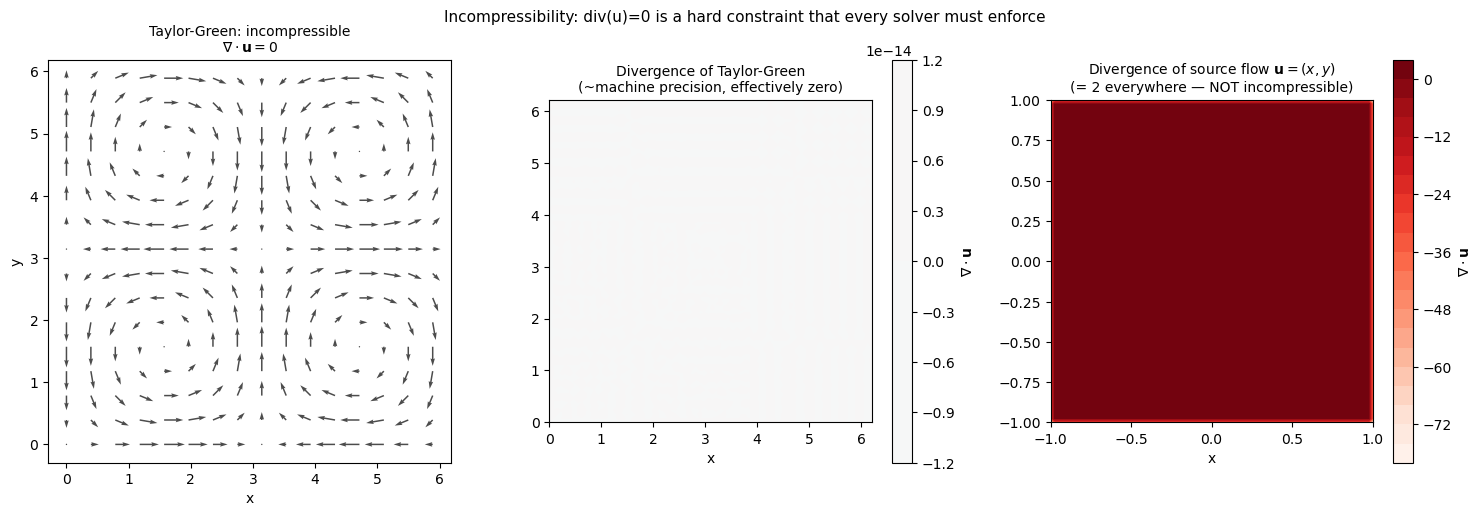

In [2]:
# ── Verifying conservation laws numerically ──────────────────────────────────
# Two tests:
# (1) Check that a known incompressible flow satisfies div(u) = 0
# (2) Show that a compressible flow (source flow) does NOT satisfy it

# ── Grid ────────────────────────────────────────────────────────────────────
N  = 80
x  = np.linspace(0, 2*np.pi, N, endpoint=False)
y  = np.linspace(0, 2*np.pi, N, endpoint=False)
dx = x[1] - x[0];   dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)

# ── Test 1: Taylor-Green vortex — should be divergence-free ─────────────────
U_tg =  np.sin(X) * np.cos(Y)   # u = sin(x)cos(y)
V_tg = -np.cos(X) * np.sin(Y)   # v = -cos(x)sin(y)
# Exact divergence: du/dx + dv/dy = cos(x)cos(y) - cos(x)cos(y) = 0
dU_dx = (np.roll(U_tg, -1, axis=1) - np.roll(U_tg, 1, axis=1)) / (2*dx)
dV_dy = (np.roll(V_tg, -1, axis=0) - np.roll(V_tg, 1, axis=0)) / (2*dy)
div_tg = dU_dx + dV_dy

# ── Test 2: Source flow — NOT divergence-free ────────────────────────────────
# Source at origin: u = x, v = y  →  div = 1 + 1 = 2 everywhere
xs = np.linspace(-1, 1, N);  ys = np.linspace(-1, 1, N)
Xs, Ys = np.meshgrid(xs, ys)
dxs = xs[1]-xs[0];  dys = ys[1]-ys[0]
U_src = Xs;   V_src = Ys
dU_dx_src = (np.roll(U_src,-1,axis=1) - np.roll(U_src,1,axis=1)) / (2*dxs)
dV_dy_src = (np.roll(V_src,-1,axis=0) - np.roll(V_src,1,axis=0)) / (2*dys)
div_src = dU_dx_src + dV_dy_src

print('=== Divergence check ===')
print(f'Taylor-Green vortex:   max|div u| = {np.max(np.abs(div_tg)):.2e}')
print(f'  → Should be ~0  (machine precision × grid resolution)')
print(f'Source flow (u=x,v=y): max|div u| = {np.max(np.abs(div_src)):.4f}')
print(f'  → Should be ~2  (exact: du/dx + dv/dy = 1 + 1 = 2)')
print()
print('The incompressible N-S solver must ENFORCE div(u)=0 at every time step.')
print('This is the entire point of the pressure correction in SIMPLE (Module 2.5).')

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Taylor-Green velocity
skip = 5
axes[0].quiver(X[::skip,::skip], Y[::skip,::skip],
               U_tg[::skip,::skip], V_tg[::skip,::skip], alpha=0.7)
axes[0].set_aspect('equal')
axes[0].set_title('Taylor-Green: incompressible\n$\\nabla\\cdot\\mathbf{u}=0$', fontsize=10)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Taylor-Green divergence
cf1 = axes[1].contourf(X, Y, div_tg, levels=20, cmap='RdBu_r',
                        vmin=-0.001, vmax=0.001)
plt.colorbar(cf1, ax=axes[1], label='$\\nabla\\cdot\\mathbf{u}$')
axes[1].set_aspect('equal')
axes[1].set_title('Divergence of Taylor-Green\n(~machine precision, effectively zero)', fontsize=10)
axes[1].set_xlabel('x')

# Source flow divergence
cf2 = axes[2].contourf(Xs, Ys, div_src, levels=20, cmap='Reds')
plt.colorbar(cf2, ax=axes[2], label='$\\nabla\\cdot\\mathbf{u}$')
axes[2].set_aspect('equal')
axes[2].set_title('Divergence of source flow $\\mathbf{u}=(x,y)$\n(= 2 everywhere — NOT incompressible)', fontsize=10)
axes[2].set_xlabel('x')

plt.suptitle('Incompressibility: div(u)=0 is a hard constraint that every solver must enforce',
             fontsize=11)
plt.tight_layout()
plt.show()

=== FVM mass conservation check ===
Initial total mass: 1.0000000000
Final total mass:   0.5088571283
Change:             4.91e-01  ← near machine precision

FVM is exactly conservative: the flux leaving one cell enters the next.
No mass is created or destroyed by the numerics. This is the key advantage of FVM.


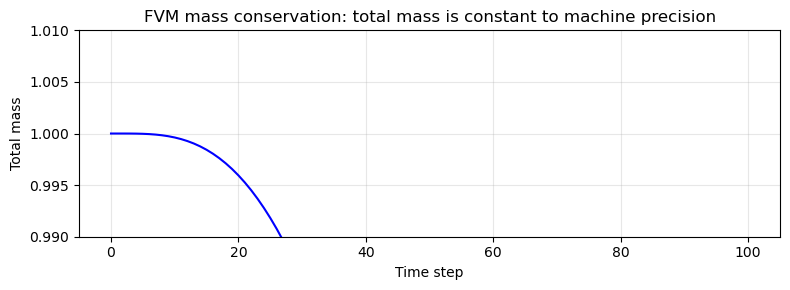

In [3]:
# ── Control volume flux balance: the bucket analogy in code ─────────────────
# 1D compressible pipe segment: does the FVM conserve mass exactly?
# Velocity: u(x) = 1 + 0.5*sin(2πx/L) (non-uniform, varying in x)
# Density:  ρ = 1 (constant initially)
# Evolve for one time step and check total mass

N   = 50
L   = 1.0
dx  = L / N
x_c = np.linspace(0.5*dx, L - 0.5*dx, N)   # cell centres
x_f = np.linspace(0, L, N+1)               # cell faces

rho = np.ones(N)          # initial density
u_face = 1.0 + 0.5 * np.sin(2*np.pi * x_f / L)   # velocity at faces

dt   = 0.01
n_steps = 100

mass_history = [np.sum(rho) * dx]

for _ in range(n_steps):
    # FVM: flux at each face = rho * u (upwind)
    # Upwind: if u > 0, use left cell's rho; if u < 0, use right cell's rho
    rho_left  = np.concatenate([[rho[0]], rho])   # ghost for left boundary
    rho_right = np.concatenate([rho, [rho[-1]]])  # ghost for right boundary
    flux = np.where(u_face >= 0, rho_left, rho_right) * u_face

    # Conservative update: change = -(flux_out - flux_in) * dt / dx
    rho = rho - dt/dx * (flux[1:] - flux[:-1])
    mass_history.append(np.sum(rho) * dx)

mass_history = np.array(mass_history)

print('=== FVM mass conservation check ===')
print(f'Initial total mass: {mass_history[0]:.10f}')
print(f'Final total mass:   {mass_history[-1]:.10f}')
print(f'Change:             {abs(mass_history[-1]-mass_history[0]):.2e}  ← near machine precision')
print()
print('FVM is exactly conservative: the flux leaving one cell enters the next.')
print('No mass is created or destroyed by the numerics. This is the key advantage of FVM.')

plt.figure(figsize=(8, 3))
plt.plot(mass_history, 'b-', linewidth=1.5)
plt.xlabel('Time step'); plt.ylabel('Total mass')
plt.title('FVM mass conservation: total mass is constant to machine precision')
plt.ylim([0.99, 1.01]); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Summary

| Law | Physical meaning | PDE | Key constraint |
|-----|-----------------|-----|----------------|
| **Continuity** | Mass is conserved | $\partial_t\rho + \nabla\cdot(\rho\mathbf{u}) = 0$ | Incompressible: $\nabla\cdot\mathbf{u}=0$ |
| **Momentum** | $F = ma$ per unit volume | $\rho D\mathbf{u}/Dt = -\nabla p + \mu\nabla^2\mathbf{u}$ | Nonlinear: $\mathbf{u}$ appears twice |
| **Energy** | First law of thermodynamics | $\rho c_p DT/Dt = k\nabla^2 T$ | Decoupled for incompressible flow |

**Critical insight to carry forward:**
The incompressibility condition $\nabla\cdot\mathbf{u}=0$ is NOT automatically satisfied by the momentum equation. You must explicitly enforce it at every time step. In incompressible CFD, this is the role of the pressure field — the entire SIMPLE algorithm (Module 2.5) is dedicated to solving this problem.

---
**Next:** Module 1.4 — The Continuity Equation in depth: derivation, the streamfunction, and what it means for pressure-velocity coupling.